# 基于机器学习的岩石力学研究

## Data Preprocess

In [1]:
from base import *
from numpy.random import choice
import warnings
warnings.filterwarnings('ignore')

dict_type = {"安山岩": 0,
             "白云岩": 1,
             "板岩":   2,
             "大理岩": 3,
             "辉长岩": 4,
             "砾岩":   5,
             "流纹岩": 6,
             "片麻岩": 7,
             "砂岩":   8,
             "闪长岩": 9,
             "石灰岩": 10,
             "石英":   11,
             "玄武岩": 12,
             "页岩":   13,
             "正长岩": 14}

data_dir = "./data"
num = 396

- Test dataset

In [2]:
dict_train_samples = {}
dict_test_samples = {}

for type in dict_type.keys():
    dict_train_samples[type] = []
    dict_test_samples[type] = []
    ids_test = choice(list(range(num)), (int)(num * P_TEST))
    for i in range(num):
        if i not in ids_test:
            dict_train_samples[type].append(Sample(os.path.join(data_dir, type, str(i)), type))
        else:
            dict_test_samples[type].append(Sample(os.path.join(data_dir, type, str(i)), type))

raw_X_train = []
raw_Y_train = []
raw_T_train = []
raw_X_test = []
raw_Y_test = []
raw_T_test = []

for type in dict_type.keys():
    for sample in dict_train_samples[type]:
        raw_X_train.append(sample.feature)
        raw_Y_train.append(sample.target)
        raw_T_train.append(np.array([dict_type[type]]))
    for sample in dict_test_samples[type]:
        raw_X_test.append(sample.feature)
        raw_Y_test.append(sample.target)
        raw_T_test.append(np.array([dict_type[type]]))

raw_X_train = np.stack(raw_X_train)
raw_Y_train = np.stack(raw_Y_train)
T_train = np.concatenate(raw_T_train)

raw_X_test = np.stack(raw_X_test)
raw_Y_test = np.stack(raw_Y_test)
T_test = np.concatenate(raw_T_test)

- Normalization

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

X_scaler = StandardScaler()
X_train = X_scaler.fit_transform(raw_X_train)
X_test = X_scaler.transform(raw_X_test)

Y_scaler = StandardScaler()
Y_train = Y_scaler.fit_transform(raw_Y_train)
Y_test = Y_scaler.transform(raw_Y_test)

X_train, Y_train, T_train = shuffle(X_train, Y_train, T_train, random_state=SEED)
X_test, Y_test, T_test = shuffle(X_test, Y_test, T_test, random_state=SEED)

## Classification

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

train_accuracy = {}
train_precision = {}
train_recall = {}
train_f1_score = {}

test_accuracy = {}
test_precision = {}
test_recall = {}
test_f1_score = {}

models = {}

def model_assess(name: str, model):
    model.fit(X_train, T_train)
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_accuracy[name] = accuracy_score(T_train, train_preds)
    train_precision[name] = precision_score(T_train, train_preds, average=None)
    train_recall[name] = recall_score(T_train, train_preds, average=None)
    train_f1_score[name] = f1_score(T_train, train_preds, average=None)

    test_accuracy[name] = accuracy_score(T_test, test_preds)
    test_precision[name] = precision_score(T_test, test_preds, average=None)
    test_recall[name] = recall_score(T_test, test_preds, average=None)
    test_f1_score[name] = f1_score(T_test, test_preds, average=None)

    print(f"Model: {name}\n" +
          f"accuracy:  {np.mean(test_accuracy[name]):.6f}\n" +
          f"precision: {np.mean(test_precision[name]):.6f}\n" +
          f"recall:    {np.mean(test_recall[name]):.6f}\n" +
          f"f1_score:  {np.mean(test_f1_score[name]):.6f}\n")

- L1逻辑回归

In [5]:
from sklearn.linear_model import LogisticRegression

models["LR_L1"] = LogisticRegression(penalty="l1", solver="liblinear", C=1, max_iter=10000, random_state=SEED)
model_assess("LR_L1", models["LR_L1"])

Model: LR_L1
accuracy:  0.339239
precision: 0.333789
recall:    0.338789
f1_score:  0.318604



- L2逻辑回归

In [6]:
from sklearn.linear_model import LogisticRegression

models["LR_L2"] = LogisticRegression(penalty="l2", C=1, max_iter=10000, random_state=SEED)
model_assess("LR_L2", models["LR_L2"])

Model: LR_L2
accuracy:  0.317585
precision: 0.322616
recall:    0.315451
f1_score:  0.292895



- 决策树

In [7]:
from sklearn.tree import DecisionTreeClassifier

models["DT"] = DecisionTreeClassifier(criterion="entropy", random_state=SEED)
model_assess("DT", models["DT"])

Model: DT
accuracy:  0.942257
precision: 0.947267
recall:    0.943721
f1_score:  0.942362



- 随机森林

In [8]:
from sklearn.ensemble import RandomForestClassifier

models["RF"] = RandomForestClassifier(n_estimators=500, random_state=SEED)
model_assess("RF", models["RF"])

Model: RF
accuracy:  0.942913
precision: 0.946029
recall:    0.944523
f1_score:  0.944263



- 朴素贝叶斯

In [9]:
from sklearn.naive_bayes import GaussianNB

models["NB"] = GaussianNB()
model_assess("NB", models["NB"])

Model: NB
accuracy:  0.206037
precision: 0.206981
recall:    0.205418
f1_score:  0.181914



- K近邻

In [10]:
from sklearn.neighbors import KNeighborsClassifier

models["KNN"] = KNeighborsClassifier(n_neighbors = 9)
model_assess("KNN", models["KNN"])

Model: KNN
accuracy:  0.916667
precision: 0.922809
recall:    0.917938
f1_score:  0.916457



- 支持向量机

In [11]:
from sklearn.svm import SVC

models["SVM"] = SVC(random_state=SEED)
model_assess("SVM", models["SVM"])

Model: SVM
accuracy:  0.551181
precision: 0.574886
recall:    0.551885
f1_score:  0.531096



- Boosting

In [12]:
from sklearn.ensemble import AdaBoostClassifier

models["AB"] = AdaBoostClassifier(n_estimators=50, learning_rate=0.1, random_state=SEED)
model_assess("AB", models["AB"])

Model: AB
accuracy:  0.221129
precision: 0.216523
recall:    0.219026
f1_score:  0.171394



In [13]:
from sklearn.ensemble import GradientBoostingClassifier

models["GB"] = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, random_state=SEED)
model_assess("GB", models["GB"])

Model: GB
accuracy:  0.940945
precision: 0.945878
recall:    0.942426
f1_score:  0.941006



In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_acc():
    plt.rcParams['figure.figsize'] = (10, 4)
    sns.set_style('darkgrid')
    ax = sns.barplot(x=list(test_accuracy.keys()), y=list(test_accuracy.values()), palette = "coolwarm", saturation = 2.0)
    plt.xlabel('Classifier Models', fontsize = 12)
    plt.ylabel('Accuracy', fontsize = 12)
    plt.title('Accuracy of different Classifier Models', fontsize = 16)
    plt.xticks(fontsize = 12, horizontalalignment = 'center')
    plt.yticks(fontsize = 12)
    for i in ax.patches:
        width, height = i.get_width(), i.get_height()
        x, y = i.get_xy()
        ax.annotate(f'{round(height, 3)}', (x + width / 2, y + height), ha='center', fontsize = 'x-large')
    plt.show()

def plot_f1():
    plt.rcParams['figure.figsize'] = (10, 4)
    sns.set_style('darkgrid')
    ax = sns.barplot(x=list(test_f1_score.keys()), y=[np.mean(sub) for sub in test_f1_score.values()], palette = "coolwarm", saturation = 2.0)
    plt.xlabel('Classifier Models', fontsize = 12)
    plt.ylabel('F1', fontsize = 12)
    plt.title('F1 of different Classifier Models', fontsize = 16)
    plt.xticks(fontsize = 12, horizontalalignment = 'center')
    plt.yticks(fontsize = 12)
    for i in ax.patches:
        width, height = i.get_width(), i.get_height()
        x, y = i.get_xy()
        ax.annotate(f'{round(height, 3)}', (x + width / 2, y + height), ha='center', fontsize = 'x-large')
    plt.show()

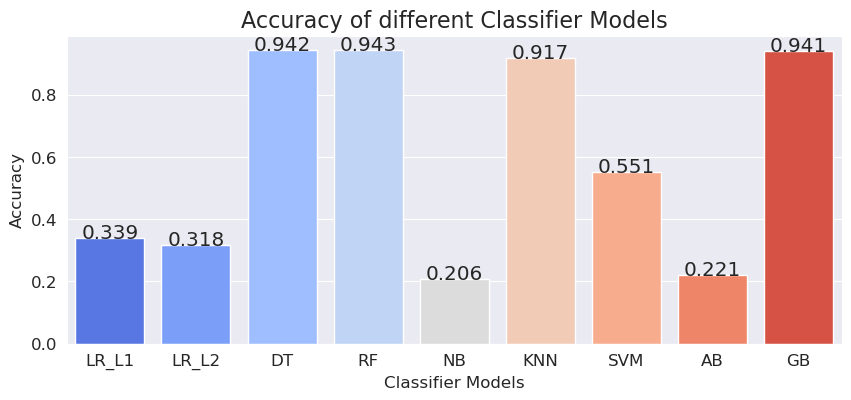

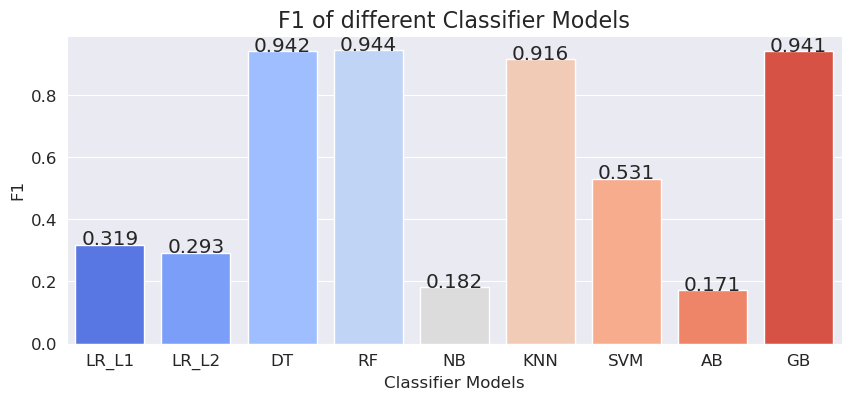

In [20]:
plot_acc()
plot_f1()

## Regression

In [60]:
from sklearn.metrics import mean_squared_error, r2_score

train_mse = {}
train_r2 = {}

test_mse = {}
test_r2 = {}

models = {}

def model_assess(name: str, model, i):
    model.fit(X_train, Y_train[:, i])
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_mse[name] = mean_squared_error(Y_train[:, i], train_preds)
    train_r2[name] = r2_score(Y_train[:, i], train_preds)

    test_mse[name] = mean_squared_error(Y_test[:, i], test_preds)
    test_r2[name] = r2_score(Y_test[:, i], test_preds)

    print(f"Model: {name}\n" +
          f"mse: {test_mse[name]:.6f}\n" +
          f"r2:  {test_r2[name]:.6f}\n")

In [61]:
from sklearn.linear_model import LinearRegression

models["LR"] = LinearRegression()
model_assess("LR", models["LR"], 0)

Model: LR
mse: 0.920524
r2:  0.012995



In [63]:
from sklearn.tree import DecisionTreeRegressor

models["DT"] = DecisionTreeRegressor(criterion='squared_error', random_state=SEED)
model_assess("DT", models["DT"], 0)

Model: DT
mse: 0.807895
r2:  0.133759



In [62]:
from sklearn.ensemble import GradientBoostingRegressor

models["GB"] = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, random_state=SEED)
model_assess("GB", models["GB"], 0)

Model: GB
mse: 0.821323
r2:  0.119360



In [64]:
from sklearn.neural_network import MLPRegressor

models["MLP"] =  MLPRegressor(hidden_layer_sizes = (10, 20, 10), activation = "relu", alpha = 0.01, max_iter=1000, random_state=SEED)
model_assess("MLP", models["MLP"], 0)

Model: MLP
mse: 0.831646
r2:  0.108292



In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_mse():
    plt.rcParams['figure.figsize'] = (6, 4)
    sns.set_style('darkgrid')
    ax = sns.barplot(x=list(test_mse.keys()), y=list(test_mse.values()), palette = "coolwarm", saturation = 2.0)
    plt.xlabel('Regression Models', fontsize = 12)
    plt.ylabel('MSE', fontsize = 12)
    plt.title('MSE of different Regression Models', fontsize = 16)
    plt.xticks(fontsize = 12, horizontalalignment = 'center')
    plt.yticks(fontsize = 12)
    for i in ax.patches:
        width, height = i.get_width(), i.get_height()
        x, y = i.get_xy()
        ax.annotate(f'{round(height, 3)}', (x + width / 2, y + height), ha='center', fontsize = 'x-large')
    plt.show()


def plot_r2():
    plt.rcParams['figure.figsize'] = (6, 4)
    sns.set_style('darkgrid')
    ax = sns.barplot(x=list(test_r2.keys()), y=list(test_r2.values()), palette = "coolwarm", saturation = 2.0)
    plt.xlabel('Regression Models', fontsize = 12)
    plt.ylabel('R2', fontsize = 12)
    plt.title('R2 of different Regression Models', fontsize = 16)
    plt.xticks(fontsize = 12, horizontalalignment = 'center')
    plt.yticks(fontsize = 12)
    for i in ax.patches:
        width, height = i.get_width(), i.get_height()
        x, y = i.get_xy()
        ax.annotate(f'{round(height, 3)}', (x + width / 2, y + height), ha='center', fontsize = 'x-large')
    plt.show()

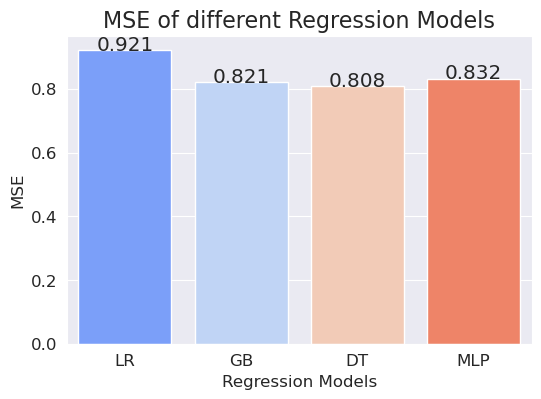

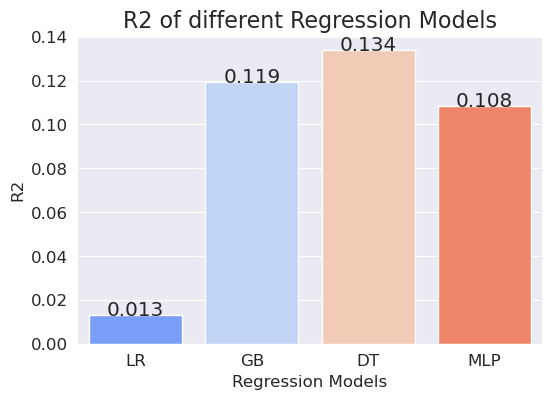

In [66]:
plot_mse()
plot_r2()